In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
df =  pd.read_csv("/content/drive/MyDrive/Methene-Emission-Classificatin/SEALS-4_Month_Data_Summary.xlsx - Sheet1.csv")
df.head()

,Start,End,Duration (seconds),EPID,Equipment,Latitude,Longitude,Height (m),Methane Emission (kg/h),Type,Emission Category
0,3/1/23 3:10,3/1/23 4:55,6299,4S-22,Separator,40.595663,-105.140262,1.40,0.1999,Separator Pneumatic Emissions,Vented
1,3/1/23 3:10,3/1/23 6:10,10800,5W-31,Well Head,40.595680,-105.139374,0.10,0.1928,Wellhead Component Leak,Fugitive
2,3/1/23 4:55,3/1/23 6:10,4501,4S-22,Separator,40.595663,-105.140262,1.40,0.2000,Separator Pneumatic Emissions,Vented
3,3/1/23 11:07,3/1/23 14:54,13627,1W-12,Well Head,40.595079,-105.139413,1.90,0.2071,Wellhead Component Leak,Fugitive
4,3/1/23 11:07,3/1/23 14:54,13608,2W-11,Well Head,40.595118,-105.140089,0.92,0.2258,Wellhead Component Leak,Fugitive


In [15]:
!cp *.png /content/drive/MyDrive/Methene-Emission-Classificatin/


In [4]:
df.columns

Index(['Start', 'End', 'Duration (seconds)', 'EPID', 'Equipment', 'Latitude',
       'Longitude', 'Height (m)', 'Methane Emission (kg/h)', 'Type',
       'Emission Category'],
      dtype='object')

In [5]:
!pwd

/content


In [ ]:
# #!git clone https://github.com/google-research/tabfm.git
# %cd tabfm
# !pip install -e .[pytorch]

In [6]:
# Clone current GitHub version
!git clone https://github.com/google-research/tabfm.git

%cd /content/tabfm

# Remove the conflicting Colab package if you don't need it
!pip uninstall -y inflect

# Install TabFM PyTorch backend
!pip install -e ".[pytorch]"

## Restart the session after running this cell.

Cloning into 'tabfm'...
remote: Enumerating objects: 666, done.
remote: Counting objects: 100% (370/370), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 666 (delta 321), reused 265 (delta 265), pack-reused 296 (from 2)
Receiving objects: 100% (666/666), 344.11 KiB | 1.54 MiB/s, done.
Resolving deltas: 100% (442/442), done.
/content/tabfm
Found existing installation: inflect 7.5.0
Uninstalling inflect-7.5.0:
  Successfully uninstalled inflect-7.5.0
Obtaining file:///content/tabfm
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 3.2 MB/s eta 0:00:00
  Building editable for tabfm (pyproject.toml) ... done
  Created wheel for tabfm: filename=tabfm-1.0.1-py3-none-any.whl size=7914 sha256=9bc11933ba9aee04f74b864a629ff4dbbe69250547934edc20fa774526a8cd34
  S

In [ ]:
# %cd /content/tabfm

# import tabfm
# import typeguard
# import jaxtyping

# print("TabFM imported successfully")
# print("typeguard:", typeguard.__version__)
# print("jaxtyping:", jaxtyping.__version__)

/content/tabfm
TabFM imported successfully


AttributeError: module 'typeguard' has no attribute '__version__'

In [1]:
import torch
import tabfm

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

model = tabfm.tabfm_v1_0_0_pytorch.load(
    "classification",
    device=device
)

print("TabFM classification model loaded successfully")

Device: cuda


config.json:   0%|          | 0.00/97.0 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights from local directory
TabFM classification model loaded successfully


In [6]:
### test the model using sythetic data
import numpy as np
import pandas as pd
from tabfm import TabFMClassifier

# Choose your backend:

# # OPTION A: JAX Backend
# from tabfm import tabfm_v1_0_0_jax as tabfm_v1_0_0
# model = tabfm_v1_0_0.load()

# #OPTION B: PyTorch Backend
# from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0
# model = tabfm_v1_0_0.load()

# Initialize scikit-learn compatible classifier (works with either backend model)
#clf = TabFMClassifier(model=model)

TABFM_N_ESTIMATORS = 32
clf = TabFMClassifier(model=model, n_estimators=
            TABFM_N_ESTIMATORS,
)




print("TabFM classification model loaded successfully")

# Prepare your dataset (supports mixed numerical and categorical features)
X_train = pd.DataFrame({
    "age": [25.0, 45.0, 35.0, 50.0],
    "job": ["engineer", "manager", "engineer", "manager"],
    "income": [80000, 120000, 90000, 130000]
})
y_train = np.array(["low_risk", "high_risk", "low_risk", "high_risk"])

X_test = pd.DataFrame({
    "age": [30.0, 48.0],
    "job": ["engineer", "manager"],
    "income": [85000, 125000]
})

print("TabFM classification model - fit")
# Fit classifier (prepares ordinal encoders and numerical scalers)
clf.fit(X_train, y_train)


print("TabFM classification model - predict")
# Predict classes and probabilities
predictions = clf.predict(X_test)

print("TabFM classification model - predict_proba")
probabilities = clf.predict_proba(X_test)

print("Predictions:", predictions)
print("Class Probabilities:\n", probabilities)

TabFM classification model loaded successfully
TabFM classification model - fit
TabFM classification model - predict
TabFM classification model - predict_proba
Predictions: ['low_risk' 'high_risk']
Class Probabilities:
 [[0.13986562 0.8601343 ]
 [0.8495001  0.15049984]]


FEW-SHOT METHANE CLASSIFICATION
Device: cuda
Shots/class: [5, 10, 20, 25]
Repeats: 5

Dataset size: 2329

Class counts:
Target
0     806
1    1523
Name: count, dtype: int64

Rolling folds: 14


TRAINING CLASS AVAILABILITY
Fold  1: Vented= 308, Fugitive= 319
Fold  2: Vented= 544, Fugitive= 412
Fold  3: Vented= 481, Fugitive= 572
Fold  4: Vented= 469, Fugitive= 627
Fold  5: Vented= 418, Fugitive= 574
Fold  6: Vented=  33, Fugitive= 510
Fold  7: Vented=  28, Fugitive= 248
Fold  8: Vented=  48, Fugitive=  70
Fold  9: Vented=  72, Fugitive=  58
Fold 10: Vented=  91, Fugitive= 222
Fold 11: Vented=  72, Fugitive= 275
Fold 12: Vented=  78, Fugitive= 309
Fold 13: Vented=  60, Fugitive= 288
Fold 14: Vented=  64, Fugitive= 200


LOADING TABFM
TabFM loaded.


##############################################################################################################

5-SHOT PER CLASS | FOLD 2/14 | Time: 2026-08-29 06:06:08
#########################################################################

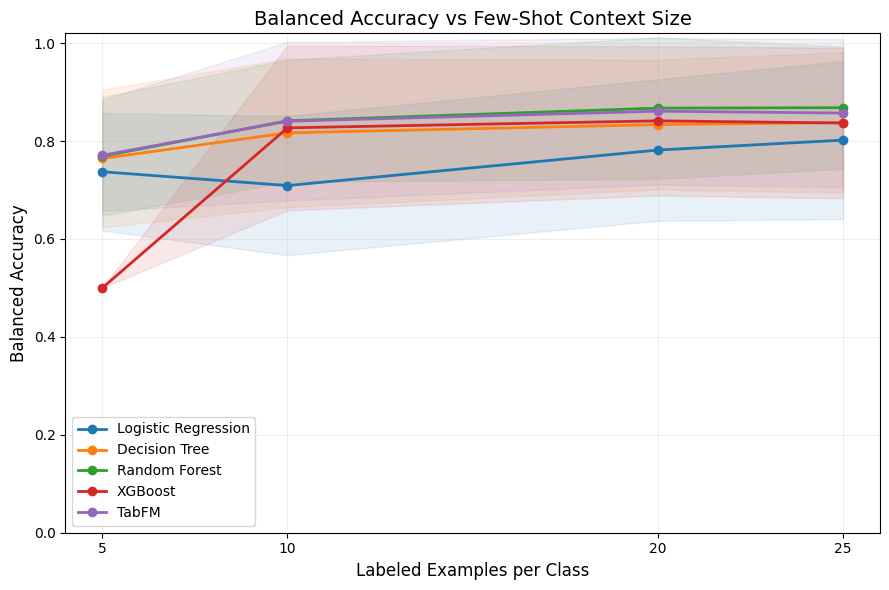

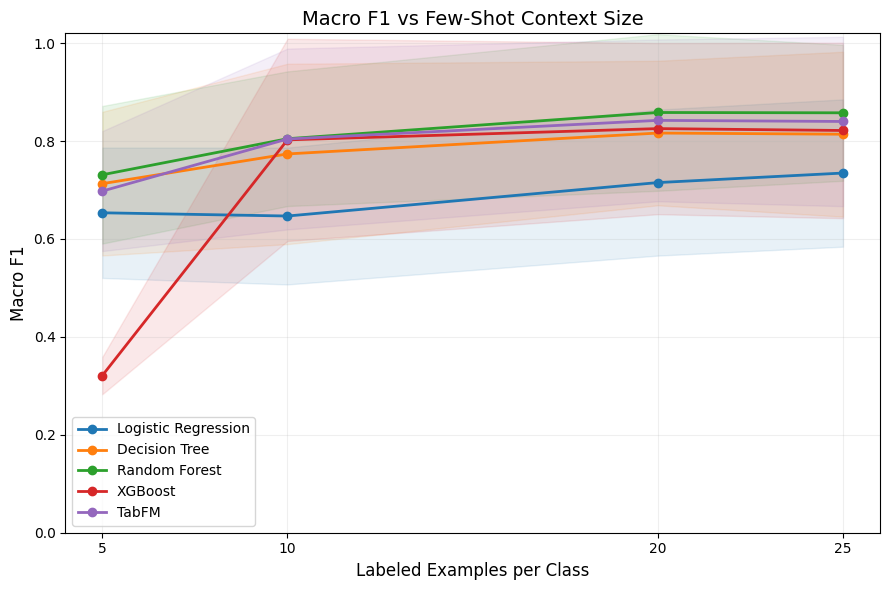

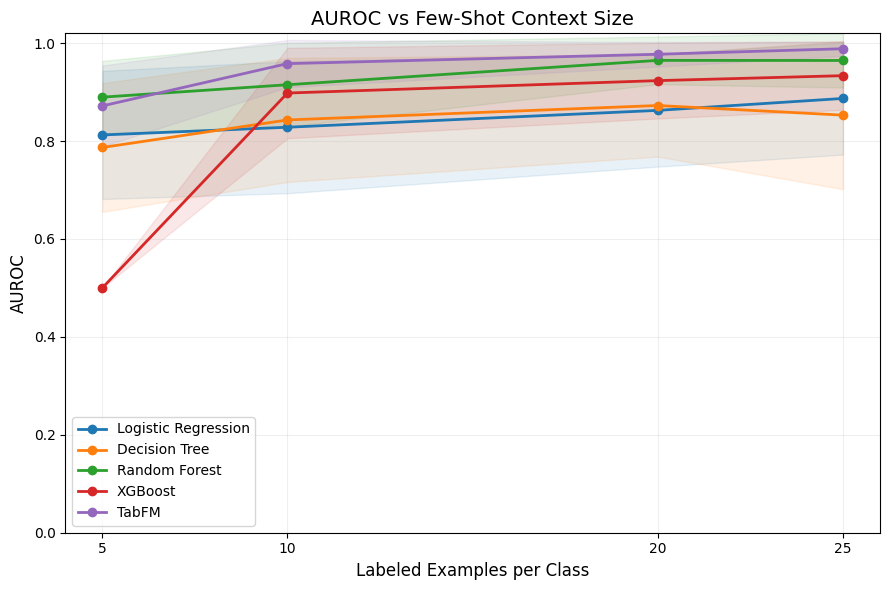

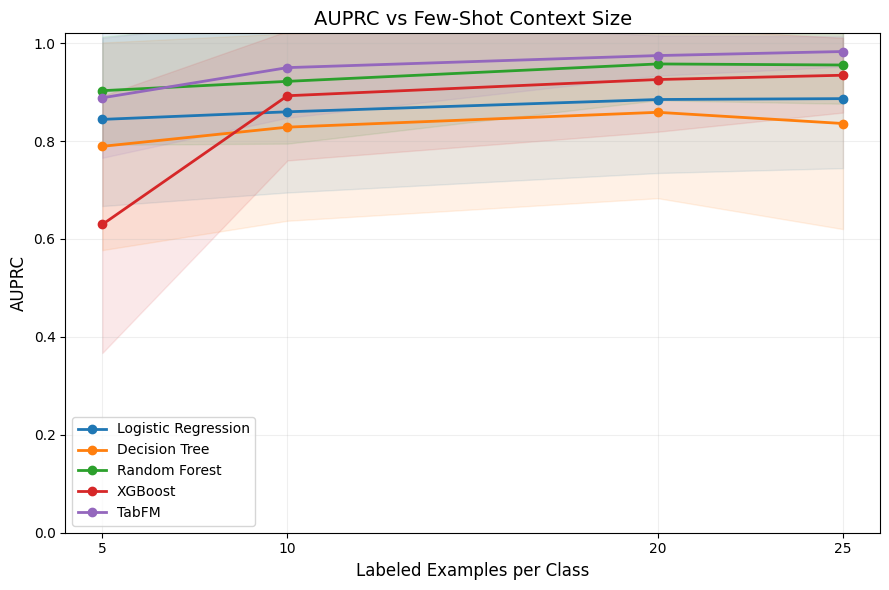



COMPACT PAPER TABLE

5 examples/class (10 total labeled examples)
              Model Balanced Accuracy      F1 Macro         AUROC         AUPRC
Logistic Regression     0.737 ± 0.120 0.653 ± 0.133 0.812 ± 0.131 0.844 ± 0.177
      Decision Tree     0.764 ± 0.141 0.713 ± 0.147 0.787 ± 0.132 0.789 ± 0.212
      Random Forest     0.769 ± 0.121 0.731 ± 0.141 0.890 ± 0.074 0.903 ± 0.110
            XGBoost     0.500 ± 0.000 0.321 ± 0.038 0.500 ± 0.000 0.630 ± 0.262
              TabFM     0.771 ± 0.114 0.698 ± 0.123 0.872 ± 0.082 0.888 ± 0.122

10 examples/class (20 total labeled examples)
              Model Balanced Accuracy      F1 Macro         AUROC         AUPRC
Logistic Regression     0.709 ± 0.142 0.647 ± 0.140 0.828 ± 0.135 0.860 ± 0.165
      Decision Tree     0.817 ± 0.152 0.774 ± 0.184 0.843 ± 0.127 0.828 ± 0.191
      Random Forest     0.841 ± 0.125 0.805 ± 0.138 0.915 ± 0.086 0.922 ± 0.127
            XGBoost     0.827 ± 0.168 0.802 ± 0.206 0.898 ± 0.092 0.893 ± 0.132
     

In [8]:
# ============================================================
# FEW-SHOT / CONTEXT-SIZE BENCHMARK
#
# Methane classification:
#     Fugitive = 1
#     Vented   = 0
#
# Same features for ALL models:
#     Equipment
#     Methane Emission (kg/h)
#     Duration (seconds)
#     Height (m)
#
# Few-shot settings:
#     5 / 10 / 20 / 25 examples PER CLASS
#
# Temporal evaluation:
#     Previous 30 days -> candidate training/context pool
#     Next 7 days      -> untouched future test set
#     Step             -> 7 days
#
# IMPORTANT:
# For each:
#     fold × shot size × repeat
#
# EXACTLY THE SAME sampled rows are used by:
#     Logistic Regression
#     Decision Tree
#     Random Forest
#     XGBoost
#     TabFM
#
# TabFM:
#     no task-specific parameter updates
#     sampled labeled rows are used as ICL context
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import gc
import warnings
import random

from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    matthews_corrcoef
)

from xgboost import XGBClassifier

import tabfm


warnings.filterwarnings("ignore")


# ============================================================
# 1. SETTINGS
# ============================================================

FILE_PATH = (
    "/content/drive/MyDrive/"
    "Methene-Emission-Classificatin/"
    "SEALS-4_Month_Data_Summary.xlsx - Sheet1.csv"
)

TRAIN_DAYS = 30
TEST_DAYS = 7
STEP_DAYS = 7

RANDOM_STATE = 42


# ------------------------------------------------------------
# Few-shot settings
# ------------------------------------------------------------

SHOTS_PER_CLASS = [
    5,
    10,
    20,
    25
]


# Repeat random sampling because few-shot results can vary
# substantially depending on which examples are selected.
#
# For final paper:
#   5 is reasonable
#   10 is even stronger if runtime permits.
N_REPEATS = 5


# ------------------------------------------------------------
# TabFM settings
# ------------------------------------------------------------

TABFM_N_ESTIMATORS = 32

TABFM_BATCH_SIZE = 4


DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("=" * 100)
print("FEW-SHOT METHANE CLASSIFICATION")
print("=" * 100)

print("Device:", DEVICE)
print("Shots/class:", SHOTS_PER_CLASS)
print("Repeats:", N_REPEATS)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)


# ============================================================
# 3. LOAD DATA
# ============================================================

df = pd.read_csv(
    FILE_PATH
)


# ============================================================
# 4. KEEP ONLY BINARY CLASSES
# ============================================================

df = df[
    df["Emission Category"].isin(
        [
            "Fugitive",
            "Vented"
        ]
    )
].copy()


# ============================================================
# 5. PARSE TIME
# ============================================================

df["Start"] = pd.to_datetime(
    df["Start"],
    errors="coerce"
)


# ============================================================
# 6. FEATURES
# ============================================================

categorical_features = [
    "Equipment"
]


numerical_features = [
    "Methane Emission (kg/h)",
    "Duration (seconds)",
    "Height (m)"
]


feature_columns = (
    categorical_features
    +
    numerical_features
)


for column in numerical_features:

    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )


# Important for TabFM categorical handling
df["Equipment"] = (
    df["Equipment"]
    .astype(str)
)


# ============================================================
# 7. REMOVE MISSING OBSERVATIONS
# ============================================================

df = df.dropna(
    subset=[
        "Start",
        "Emission Category",
        *feature_columns
    ]
)


# ============================================================
# 8. SORT CHRONOLOGICALLY
# ============================================================

df = (
    df
    .sort_values("Start")
    .reset_index(drop=True)
)


# ============================================================
# 9. TARGET
# ============================================================

df["Target"] = (
    df["Emission Category"]
    .map({
        "Vented": 0,
        "Fugitive": 1
    })
    .astype(int)
)


X = df[
    feature_columns
].copy()


y = df[
    "Target"
].astype(int)


print("\nDataset size:", len(df))

print("\nClass counts:")
print(
    y.value_counts()
    .sort_index()
)


# ============================================================
# 10. TEMPORAL ROLLING SPLITS
# ============================================================

def create_time_splits(
    dataframe,
    time_column,
    train_days=30,
    test_days=7,
    step_days=7
):

    splits = []

    first_day = (
        dataframe[time_column]
        .min()
        .normalize()
    )

    last_day = (
        dataframe[time_column]
        .max()
        .normalize()
    )

    data_end = (
        last_day
        +
        pd.Timedelta(days=1)
    )

    test_start = (
        first_day
        +
        pd.Timedelta(
            days=train_days
        )
    )

    fold = 1


    while True:

        train_end = test_start

        train_start = (
            train_end
            -
            pd.Timedelta(
                days=train_days
            )
        )

        test_end = (
            test_start
            +
            pd.Timedelta(
                days=test_days
            )
        )


        if test_end > data_end:
            break


        train_mask = (
            (
                dataframe[time_column]
                >= train_start
            )
            &
            (
                dataframe[time_column]
                < train_end
            )
        )


        test_mask = (
            (
                dataframe[time_column]
                >= test_start
            )
            &
            (
                dataframe[time_column]
                < test_end
            )
        )


        train_idx = (
            dataframe.index[
                train_mask
            ]
            .to_numpy()
        )

        test_idx = (
            dataframe.index[
                test_mask
            ]
            .to_numpy()
        )


        if (
            len(train_idx) > 0
            and
            len(test_idx) > 0
        ):

            splits.append({

                "Fold":
                    fold,

                "Train Start":
                    train_start,

                "Train End":
                    train_end,

                "Test Start":
                    test_start,

                "Test End":
                    test_end,

                "Train Index":
                    train_idx,

                "Test Index":
                    test_idx
            })

            fold += 1


        test_start += pd.Timedelta(
            days=step_days
        )


    return splits


time_splits = create_time_splits(

    dataframe=df,

    time_column="Start",

    train_days=TRAIN_DAYS,

    test_days=TEST_DAYS,

    step_days=STEP_DAYS
)


print(
    "\nRolling folds:",
    len(time_splits)
)


# ============================================================
# 11. VERIFY AVAILABLE TRAINING SAMPLES
# ============================================================

print("\n")
print("=" * 100)
print("TRAINING CLASS AVAILABILITY")
print("=" * 100)


for split in time_splits:

    train_idx = split[
        "Train Index"
    ]

    counts = (
        y.loc[
            train_idx
        ]
        .value_counts()
        .sort_index()
    )

    print(
        f"Fold {split['Fold']:2d}: "
        f"Vented={counts.get(0, 0):4d}, "
        f"Fugitive={counts.get(1, 0):4d}"
    )


# ============================================================
# 12. BALANCED FEW-SHOT SAMPLING
# ============================================================

def sample_balanced_training_indices(
    train_idx,
    labels,
    shots_per_class,
    seed
):

    """
    Sample exactly k observations from each class.

    SAME returned indices are subsequently supplied to
    every model.

    This guarantees a fair comparison.
    """

    rng = np.random.default_rng(
        seed
    )


    fold_labels = labels.loc[
        train_idx
    ]


    class_0_idx = (
        fold_labels[
            fold_labels == 0
        ]
        .index
        .to_numpy()
    )


    class_1_idx = (
        fold_labels[
            fold_labels == 1
        ]
        .index
        .to_numpy()
    )


    if (
        len(class_0_idx)
        <
        shots_per_class
        or
        len(class_1_idx)
        <
        shots_per_class
    ):

        return None


    sampled_0 = rng.choice(
        class_0_idx,
        size=shots_per_class,
        replace=False
    )


    sampled_1 = rng.choice(
        class_1_idx,
        size=shots_per_class,
        replace=False
    )


    sampled_idx = np.concatenate(
        [
            sampled_0,
            sampled_1
        ]
    )


    # Randomize ordering, while preserving exactly
    # the same observations.
    rng.shuffle(
        sampled_idx
    )


    return sampled_idx


# ============================================================
# 13. CLASSICAL PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore"
            ),

            categorical_features
        ),

        (
            "numerical",

            StandardScaler(),

            numerical_features
        )
    ]
)


# ============================================================
# 14. CLASSICAL MODEL FACTORY
# ============================================================

def create_classical_models(
    seed
):

    return {

        "Logistic Regression":

            LogisticRegression(

                class_weight="balanced",

                max_iter=5000,

                random_state=seed
            ),


        "Decision Tree":

            DecisionTreeClassifier(

                class_weight="balanced",

                min_samples_leaf=2,

                random_state=seed
            ),


        "Random Forest":

            RandomForestClassifier(

                n_estimators=500,

                class_weight="balanced",

                min_samples_split=5,

                min_samples_leaf=2,

                random_state=seed,

                n_jobs=-1
            ),


        "XGBoost":

            XGBClassifier(

                n_estimators=500,

                learning_rate=0.05,

                max_depth=5,

                min_child_weight=2,

                subsample=0.8,

                colsample_bytree=0.8,

                # sampled training data are exactly balanced
                scale_pos_weight=1.0,

                objective="binary:logistic",

                eval_metric="logloss",

                tree_method="hist",

                random_state=seed,

                n_jobs=-1,

                verbosity=0
            )
    }


MODEL_ORDER = [

    "Logistic Regression",

    "Decision Tree",

    "Random Forest",

    "XGBoost",

    "TabFM"
]


# ============================================================
# 15. LOAD TABFM ONCE
# ============================================================

print("\n")
print("=" * 100)
print("LOADING TABFM")
print("=" * 100)


tabfm_model = (
    tabfm
    .tabfm_v1_0_0_pytorch
    .load(

        model_type="classification",

        device=DEVICE
    )
)


print(
    "TabFM loaded."
)


# ============================================================
# 16. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    y_pred,
    y_prob
):

    y_true = np.asarray(
        y_true
    )

    y_pred = np.asarray(
        y_pred
    )

    y_prob = np.asarray(
        y_prob
    )


    result = {}


    # --------------------------------------------------------
    # Metrics that remain interpretable with a single class
    # --------------------------------------------------------

    result[
        "Accuracy"
    ] = accuracy_score(
        y_true,
        y_pred
    )


    result[
        "Precision"
    ] = precision_score(

        y_true,

        y_pred,

        pos_label=1,

        zero_division=0
    )


    result[
        "Recall"
    ] = recall_score(

        y_true,

        y_pred,

        pos_label=1,

        zero_division=0
    )


    result[
        "F1"
    ] = f1_score(

        y_true,

        y_pred,

        pos_label=1,

        zero_division=0
    )


    # --------------------------------------------------------
    # Two-class metrics
    #
    # We treat these as undefined for single-class test weeks.
    # --------------------------------------------------------

    if len(
        np.unique(
            y_true
        )
    ) == 2:


        result[
            "Balanced Accuracy"
        ] = balanced_accuracy_score(

            y_true,

            y_pred
        )


        result[
            "F1 Macro"
        ] = f1_score(

            y_true,

            y_pred,

            labels=[0, 1],

            average="macro",

            zero_division=0
        )


        cm = confusion_matrix(

            y_true,

            y_pred,

            labels=[0, 1]
        )


        tn, fp, fn, tp = (
            cm.ravel()
        )


        result[
            "Specificity"
        ] = (

            tn / (tn + fp)

            if (tn + fp) > 0

            else np.nan
        )


        result[
            "MCC"
        ] = matthews_corrcoef(

            y_true,

            y_pred
        )


        result[
            "AUROC"
        ] = roc_auc_score(

            y_true,

            y_prob
        )


        result[
            "AUPRC"
        ] = average_precision_score(

            y_true,

            y_prob
        )


    else:


        result[
            "Balanced Accuracy"
        ] = np.nan


        result[
            "F1 Macro"
        ] = np.nan


        result[
            "Specificity"
        ] = np.nan


        result[
            "MCC"
        ] = np.nan


        result[
            "AUROC"
        ] = np.nan


        result[
            "AUPRC"
        ] = np.nan


    return result


METRICS = [

    "Accuracy",

    "Balanced Accuracy",

    "Precision",

    "Recall",

    "Specificity",

    "F1",

    "F1 Macro",

    "AUROC",

    "AUPRC",

    "MCC"
]


# ============================================================
# 17. RESULT STORAGE
# ============================================================

all_run_results = []


# This stores test probabilities from every repeat.
#
# Later, for each:
#
#     shot × model × fold
#
# we average probabilities over repeats BEFORE computing
# pooled out-of-time metrics.

prediction_store = {}


# ============================================================
# 18. RUN FEW-SHOT BENCHMARK
# ============================================================

for shots in SHOTS_PER_CLASS:


    print("\n")
    print("#" * 110)

    print(
        f"\n{shots}-SHOT PER CLASS | "
        f"FOLD {fold}/{len(time_splits)} | "
        f"Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    print("#" * 110)


    for split in time_splits:


        fold = split[
            "Fold"
        ]


        train_idx = split[
            "Train Index"
        ]


        test_idx = split[
            "Test Index"
        ]


        X_test = (
            X.loc[
                test_idx
            ]
            .copy()
        )


        y_test = (
            y.loc[
                test_idx
            ]
            .to_numpy(
                dtype=np.int64
            )
        )


        print(
            f"\nFold {fold} | "
            f"Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")



        # ----------------------------------------------------
        # Initialize probability storage for this test fold
        # ----------------------------------------------------

        for model_name in MODEL_ORDER:

            key = (
                shots,
                model_name,
                fold
            )

            prediction_store[
                key
            ] = {

                "y_true":
                    y_test.copy(),

                "test_idx":
                    test_idx.copy(),

                "probabilities":
                    []
            }


        # ====================================================
        # RANDOM FEW-SHOT REPEATS
        # ====================================================

        for repeat in range(
            N_REPEATS
        ):


            # Deterministic but unique seed
            sample_seed = (
                RANDOM_STATE
                +
                shots * 1000
                +
                fold * 100
                +
                repeat
            )


            sampled_idx = (
                sample_balanced_training_indices(

                    train_idx=train_idx,

                    labels=y,

                    shots_per_class=
                        shots,

                    seed=
                        sample_seed
                )
            )


            if sampled_idx is None:

                print(
                    f"  Skipping "
                    f"shot={shots}, "
                    f"fold={fold}: "
                    f"insufficient class samples."
                )

                continue


            # ------------------------------------------------
            # EXACT SAME FEW-SHOT DATA FOR ALL MODELS
            # ------------------------------------------------

            X_train_shot = (
                X.loc[
                    sampled_idx
                ]
                .copy()
            )


            y_train_shot = (
                y.loc[
                    sampled_idx
                ]
                .to_numpy(
                    dtype=np.int64
                )
            )


            print(
                f"  Repeat "
                f"{repeat + 1}/{N_REPEATS} "
                f"| context={len(sampled_idx)}"
            )


            # =================================================
            # A. CLASSICAL ML
            # =================================================

            models = (
                create_classical_models(
                    seed=sample_seed
                )
            )


            for (
                model_name,
                classifier
            ) in models.items():


                pipeline = Pipeline(
                    [

                        (
                            "preprocessor",

                            preprocessor
                        ),

                        (
                            "classifier",

                            classifier
                        )
                    ]
                )


                pipeline.fit(

                    X_train_shot,

                    y_train_shot
                )


                probability_matrix = (
                    pipeline.predict_proba(
                        X_test
                    )
                )


                classes = (
                    pipeline
                    .named_steps[
                        "classifier"
                    ]
                    .classes_
                )


                positive_index = (
                    np.where(
                        classes == 1
                    )[0][0]
                )


                y_prob = (
                    probability_matrix[
                        :,
                        positive_index
                    ]
                )


                predicted_indices = (
                    np.argmax(
                        probability_matrix,
                        axis=1
                    )
                )


                y_pred = (
                    classes[
                        predicted_indices
                    ]
                )


                metrics = (
                    calculate_metrics(

                        y_test,

                        y_pred,

                        y_prob
                    )
                )


                row = {

                    "Shots per Class":
                        shots,

                    "Total Context":
                        2 * shots,

                    "Model":
                        model_name,

                    "Fold":
                        fold,

                    "Repeat":
                        repeat + 1,

                    "Seed":
                        sample_seed,

                    "Train Start":
                        split[
                            "Train Start"
                        ],

                    "Train End":
                        split[
                            "Train End"
                        ],

                    "Test Start":
                        split[
                            "Test Start"
                        ],

                    "Test End":
                        split[
                            "Test End"
                        ],

                    "Training Samples":
                        len(
                            sampled_idx
                        ),

                    "Test Samples":
                        len(
                            test_idx
                        )
                }


                row.update(
                    metrics
                )


                all_run_results.append(
                    row
                )


                prediction_store[
                    (
                        shots,
                        model_name,
                        fold
                    )
                ][
                    "probabilities"
                ].append(
                    y_prob
                )


            # =================================================
            # B. TABFM
            # =================================================

            clf = tabfm.TabFMClassifier(

                model=
                    tabfm_model,

                n_estimators=
                    TABFM_N_ESTIMATORS,

                # Few-shot dataset is <= 50 rows.
                # Use the entire sampled context.
                max_num_rows=None,

                batch_size=
                    TABFM_BATCH_SIZE,

                random_state=
                    sample_seed,

                verbose=False,

                feat_shuffle_method=
                    "random",

                class_shift=True,

                permute_categorical=False,

                binary_calibration_method=None,

                enable_nnls=False,

                average_logits=True,

                cache_context=False
            )


            # No neural parameter update.
            # The balanced sampled rows become ICL context.
            clf.fit(

                X_train_shot,

                y_train_shot
            )


            probability_matrix = (
                clf.predict_proba(
                    X_test
                )
            )


            classes = np.asarray(
                clf.classes_
            )


            positive_index = (
                np.where(
                    classes == 1
                )[0][0]
            )


            y_prob = (
                probability_matrix[
                    :,
                    positive_index
                ]
            )


            predicted_indices = (
                np.argmax(
                    probability_matrix,
                    axis=1
                )
            )


            y_pred = (
                classes[
                    predicted_indices
                ]
                .astype(
                    np.int64
                )
            )


            metrics = (
                calculate_metrics(

                    y_test,

                    y_pred,

                    y_prob
                )
            )


            row = {

                "Shots per Class":
                    shots,

                "Total Context":
                    2 * shots,

                "Model":
                    "TabFM",

                "Fold":
                    fold,

                "Repeat":
                    repeat + 1,

                "Seed":
                    sample_seed,

                "Train Start":
                    split[
                        "Train Start"
                    ],

                "Train End":
                    split[
                        "Train End"
                    ],

                "Test Start":
                    split[
                        "Test Start"
                    ],

                "Test End":
                    split[
                        "Test End"
                    ],

                "Training Samples":
                    len(
                        sampled_idx
                    ),

                "Test Samples":
                    len(
                        test_idx
                    )
            }


            row.update(
                metrics
            )


            all_run_results.append(
                row
            )


            prediction_store[
                (
                    shots,
                    "TabFM",
                    fold
                )
            ][
                "probabilities"
            ].append(
                y_prob
            )


            del clf

            gc.collect()


            if torch.cuda.is_available():

                torch.cuda.empty_cache()


# ============================================================
# 19. RAW RUN RESULTS
# ============================================================

run_results_df = pd.DataFrame(
    all_run_results
)


run_results_df.to_csv(

    "fewshot_all_runs.csv",

    index=False
)


print("\n")
print("=" * 120)
print("ALL FEW-SHOT RUNS COMPLETE")
print("=" * 120)

print(
    "Total model runs:",
    len(run_results_df)
)


# ============================================================
# 20. FIRST AVERAGE OVER RANDOM REPEATS WITHIN EACH FOLD
#
# This is important:
#
# We want temporal folds—not random sampling repetitions—
# to determine the reported mean ± SD.
# ============================================================

fold_mean_df = (

    run_results_df

    .groupby(
        [
            "Shots per Class",
            "Model",
            "Fold"
        ],
        as_index=False
    )[METRICS]

    .mean()
)


fold_mean_df.to_csv(

    "fewshot_fold_mean_across_repeats.csv",

    index=False
)


# ============================================================
# 21. PAPER-STYLE MEAN ± SD ACROSS TEMPORAL FOLDS
# ============================================================

summary_rows = []


for shots in SHOTS_PER_CLASS:

    for model_name in MODEL_ORDER:


        subset = fold_mean_df[
            (
                fold_mean_df[
                    "Shots per Class"
                ]
                ==
                shots
            )
            &
            (
                fold_mean_df[
                    "Model"
                ]
                ==
                model_name
            )
        ]


        row = {

            "Shots per Class":
                shots,

            "Total Context":
                2 * shots,

            "Model":
                model_name,

            "Number of Folds":
                subset[
                    "Fold"
                ].nunique()
        }


        for metric in METRICS:

            values = (
                subset[
                    metric
                ]
                .dropna()
            )


            row[
                metric + " Mean"
            ] = (
                values.mean()
                if len(values) > 0
                else np.nan
            )


            row[
                metric + " SD"
            ] = (
                values.std(ddof=1)
                if len(values) > 1
                else np.nan
            )


        summary_rows.append(
            row
        )


summary_numeric_df = pd.DataFrame(
    summary_rows
)


summary_numeric_df.to_csv(

    "fewshot_summary_numeric.csv",

    index=False
)


# ============================================================
# 22. FORMATTED TABLE
# ============================================================

formatted_rows = []


for _, row in (
    summary_numeric_df
    .iterrows()
):


    output_row = {

        "Shots/Class":
            int(
                row[
                    "Shots per Class"
                ]
            ),

        "Context":
            int(
                row[
                    "Total Context"
                ]
            ),

        "Model":
            row[
                "Model"
            ]
    }


    for metric in METRICS:


        mean_value = row[
            metric + " Mean"
        ]


        sd_value = row[
            metric + " SD"
        ]


        if (
            np.isnan(
                mean_value
            )
        ):

            output_row[
                metric
            ] = "NA"


        else:

            output_row[
                metric
            ] = (

                f"{mean_value:.3f} "
                f"± "
                f"{sd_value:.3f}"
            )


    formatted_rows.append(
        output_row
    )


formatted_df = pd.DataFrame(
    formatted_rows
)


formatted_df.to_csv(

    "fewshot_summary_mean_std.csv",

    index=False
)


print("\n")
print("=" * 170)
print("FEW-SHOT RESULTS: MEAN ± SD ACROSS TEMPORAL FOLDS")
print("=" * 170)


print(

    formatted_df[
        [
            "Shots/Class",
            "Model",
            "Balanced Accuracy",
            "F1 Macro",
            "AUROC",
            "AUPRC",
            "MCC"
        ]
    ]

    .to_string(
        index=False
    )
)


# ============================================================
# 23. POOLED OUT-OF-TIME PERFORMANCE
#
# For each test event:
# first average prediction probability across sampling repeats.
#
# This prevents repeated predictions from the same test event
# from artificially inflating the pooled test sample size.
# ============================================================

pooled_rows = []


for shots in SHOTS_PER_CLASS:


    for model_name in MODEL_ORDER:


        pooled_true = []

        pooled_prob = []


        for split in time_splits:


            fold = split[
                "Fold"
            ]


            key = (
                shots,
                model_name,
                fold
            )


            if (
                key
                not in
                prediction_store
            ):

                continue


            probs = (
                prediction_store[
                    key
                ][
                    "probabilities"
                ]
            )


            if len(probs) == 0:
                continue


            # -----------------------------------------------
            # Average over few-shot sample repetitions
            # -----------------------------------------------

            mean_probability = (
                np.mean(
                    np.stack(
                        probs,
                        axis=0
                    ),
                    axis=0
                )
            )


            y_true_fold = (
                prediction_store[
                    key
                ][
                    "y_true"
                ]
            )


            pooled_true.extend(
                y_true_fold
            )


            pooled_prob.extend(
                mean_probability
            )


        pooled_true = np.asarray(
            pooled_true
        )


        pooled_prob = np.asarray(
            pooled_prob
        )


        pooled_pred = (
            pooled_prob
            >=
            0.5
        ).astype(
            int
        )


        metrics = calculate_metrics(

            pooled_true,

            pooled_pred,

            pooled_prob
        )


        row = {

            "Shots per Class":
                shots,

            "Total Context":
                2 * shots,

            "Model":
                model_name,

            "Pooled Test Samples":
                len(
                    pooled_true
                )
        }


        row.update(
            metrics
        )


        pooled_rows.append(
            row
        )


pooled_df = pd.DataFrame(
    pooled_rows
)


pooled_df.to_csv(

    "fewshot_pooled_results.csv",

    index=False
)


print("\n")
print("=" * 150)
print("POOLED OUT-OF-TIME FEW-SHOT RESULTS")
print("=" * 150)


print(

    pooled_df[
        [
            "Shots per Class",
            "Model",
            "Balanced Accuracy",
            "F1 Macro",
            "AUROC",
            "AUPRC",
            "MCC"
        ]
    ]

    .round(4)

    .to_string(
        index=False
    )
)


# ============================================================
# 24. PLOT HELPER
# ============================================================

def plot_metric_vs_shots(
    summary_df,
    metric,
    ylabel,
    filename
):


    plt.figure(
        figsize=(
            9,
            6
        )
    )


    for model_name in MODEL_ORDER:


        subset = (
            summary_df[
                summary_df[
                    "Model"
                ]
                ==
                model_name
            ]
            .sort_values(
                "Shots per Class"
            )
        )


        x = (
            subset[
                "Shots per Class"
            ]
            .to_numpy()
        )


        mean = (
            subset[
                metric + " Mean"
            ]
            .to_numpy()
        )


        sd = (
            subset[
                metric + " SD"
            ]
            .to_numpy()
        )


        line, = plt.plot(

            x,

            mean,

            marker="o",

            linewidth=2,

            label=model_name
        )


        plt.fill_between(

            x,

            mean - sd,

            mean + sd,

            alpha=0.10,

            color=
                line.get_color()
        )


    plt.xlabel(
        "Labeled Examples per Class",
        fontsize=12
    )


    plt.ylabel(
        ylabel,
        fontsize=12
    )


    plt.title(
        f"{ylabel} vs Few-Shot Context Size",
        fontsize=14
    )


    plt.xticks(
        SHOTS_PER_CLASS
    )


    plt.ylim(
        0,
        1.02
    )


    plt.grid(
        alpha=0.2
    )


    plt.legend()


    plt.tight_layout()


    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


# ============================================================
# 25. BALANCED ACCURACY VS SHOTS
# ============================================================

plot_metric_vs_shots(

    summary_numeric_df,

    metric=
        "Balanced Accuracy",

    ylabel=
        "Balanced Accuracy",

    filename=
        "fewshot_balanced_accuracy.png"
)


# ============================================================
# 26. MACRO F1 VS SHOTS
# ============================================================

plot_metric_vs_shots(

    summary_numeric_df,

    metric=
        "F1 Macro",

    ylabel=
        "Macro F1",

    filename=
        "fewshot_macro_f1.png"
)


# ============================================================
# 27. AUROC VS SHOTS
# ============================================================

plot_metric_vs_shots(

    summary_numeric_df,

    metric=
        "AUROC",

    ylabel=
        "AUROC",

    filename=
        "fewshot_auroc.png"
)


# ============================================================
# 28. AUPRC VS SHOTS
# ============================================================

plot_metric_vs_shots(

    summary_numeric_df,

    metric=
        "AUPRC",

    ylabel=
        "AUPRC",

    filename=
        "fewshot_auprc.png"
)


# ============================================================
# 29. PRINT A COMPACT PAPER TABLE
# ============================================================

paper_metrics = [

    "Balanced Accuracy",

    "F1 Macro",

    "AUROC",

    "AUPRC"
]


print("\n")
print("=" * 150)
print("COMPACT PAPER TABLE")
print("=" * 150)


for shots in SHOTS_PER_CLASS:


    print(
        f"\n{shots} examples/class "
        f"({2 * shots} total labeled examples)"
    )


    subset = formatted_df[
        formatted_df[
            "Shots/Class"
        ]
        ==
        shots
    ]


    print(

        subset[
            [
                "Model",
                *paper_metrics
            ]
        ]

        .to_string(
            index=False
        )
    )


# ============================================================
# 30. COMPLETE
# ============================================================

print("\n")
print("=" * 100)
print("FEW-SHOT BENCHMARK COMPLETE")
print("=" * 100)

print(
    "Shots/class:",
    SHOTS_PER_CLASS
)

print(
    "Repeats:",
    N_REPEATS
)

print(
    "Rolling folds:",
    len(time_splits)
)

print(
    "Features:",
    feature_columns
)